In [28]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_blobs

In [3]:
from tensorflow.keras.activations import linear, relu, sigmoid

In [29]:
def my_softmax(z):
    ez = np.exp(z)
    a = np.exp(z)
    return(a)

In [30]:
from keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(x_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


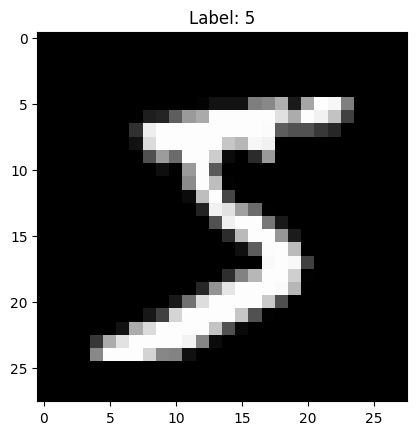

In [31]:
#Visualize the data
plt.imshow(x_train[0], cmap='gray')
plt.title('Label: {}'.format(y_train[0]))
plt.show()

In [32]:
tf.random.set_seed(1234)
model = Sequential(
    [
        tf.keras.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu', name='L1'),
        Dense(50, activation='relu', name='L2'),
        Dense(10, activation='linear', name='L3')
    ], name = 'my_model'
)

C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [33]:
model.summary()

Model: "my_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L1 (Dense)                      │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Dense)                      │ (None, 50)             │         6,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L3 (Dense)                      │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,440 (419.69 KB)

 Trainable params: 107,440 (419.69 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
[layer1, layer2, layer3, layer4] = model.layers


In [35]:
#Example Weights shape
W2, b2 = layer2.get_weights()
W3, b3 = layer3.get_weights()
W4, b4 = layer4.get_weights()
print('W1 shape: {}, b1 shape: {}'.format(W1.shape, b1.shape))
print('W2 shape: {}, b2 shape: {}'.format(W2.shape, b2.shape))
print('W3 shape: {}, b3 shape: {}'.format(W3.shape, b3.shape))
print('W4 shape: {}, b4 shape: {}'.format(W4.shape, b4.shape))

W1 shape: (28, 128), b1 shape: (128,)
W2 shape: (784, 128), b2 shape: (128,)
W3 shape: (128, 50), b3 shape: (50,)
W4 shape: (50, 10), b4 shape: (10,)


In [36]:
model.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
)

history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=10,
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 1.4343 - val_loss: 0.4619
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.3624 - val_loss: 0.2777
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.2317 - val_loss: 0.2355
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.1640 - val_loss: 0.2125
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.1405 - val_loss: 0.1856
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.1179 - val_loss: 0.1732
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.1051 - val_loss: 0.1518
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0903 - val_loss: 0.1571
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0884 - val_loss: 0.1744
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0831 - val_loss: 0.1605


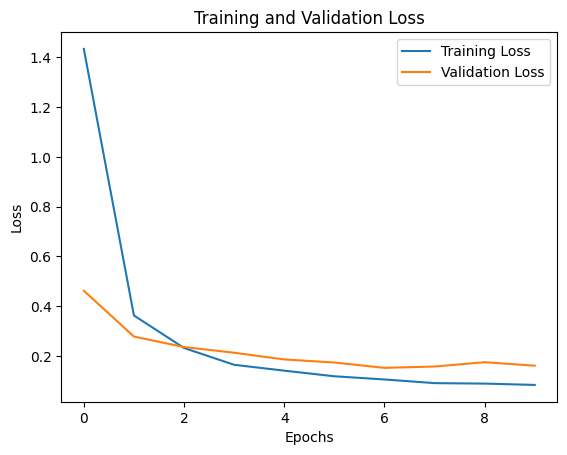

In [37]:
#Plot the training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [38]:
#Prediction
predictions = model.predict(x_test)
print(predictions[0])
print(f"Largest Prediction index: {np.argmax(predictions[0])}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[ -0.5797306  15.480079   13.601623   18.664305    2.5053499   5.3124228
 -35.511086   33.200504   -5.278554   12.854769 ]
Largest Prediction index: 7


In [39]:
prediction_p = tf.nn.softmax(predictions[0])
print(prediction_p)
print(f"Prediction probabilities: {prediction_p.numpy()}")

tf.Tensor(
[2.1351581e-15 2.0142679e-08 3.0783216e-09 4.8641681e-07 4.6694280e-14
 7.7332184e-13 1.4418959e-30 9.9999952e-01 1.9442745e-17 1.4586771e-09], shape=(10,), dtype=float32)
Prediction probabilities: [2.1351581e-15 2.0142679e-08 3.0783216e-09 4.8641681e-07 4.6694280e-14
 7.7332184e-13 1.4418959e-30 9.9999952e-01 1.9442745e-17 1.4586771e-09]


In [44]:
print(f"Predicted class: {np.argmax(predictions[0])}, True class: {y_test[0]}")

Predicted class: 7, True class: 7


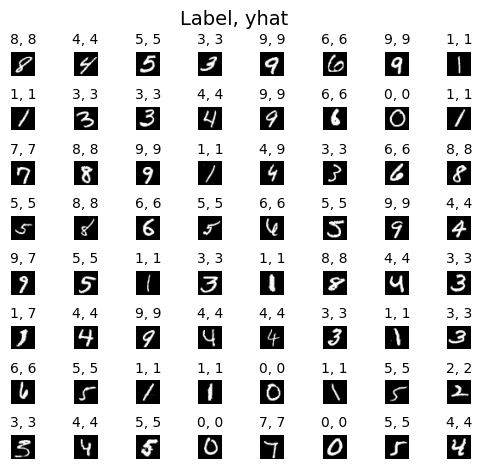

In [46]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

m = x_train.shape[0]

fig, axes = plt.subplots(8,8, figsize=(5,5))
fig.tight_layout(pad=0.13,rect=[0, 0.03, 1, 0.91])

for i, ax in enumerate(axes.flat):

    # Select random image
    random_index = np.random.randint(m)

    # Get image
    image = x_train[random_index]

    # Display image
    ax.imshow(image, cmap='gray')

    # Predict using the neural network
    prediction = model.predict(image.reshape(1,28,28), verbose=0)

    prediction_p = tf.nn.softmax(prediction)

    yhat = np.argmax(prediction_p)

    # Show true label and predicted label
    ax.set_title(f"{y_train[random_index]}, {yhat}", fontsize=10)

    ax.set_axis_off()

fig.suptitle("Label, yhat", fontsize=14)

plt.show()

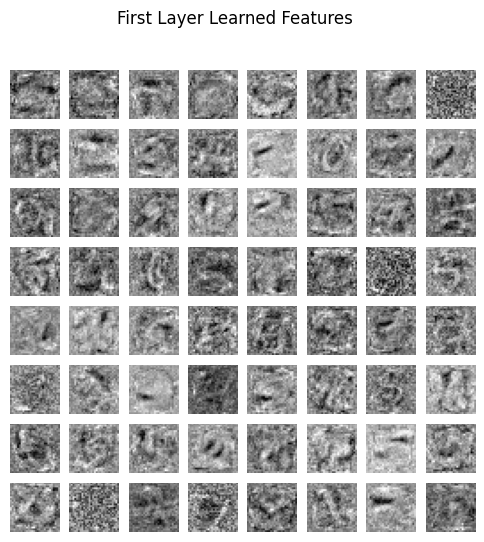

In [48]:
layer1 = model.layers[1]   # first Dense layer (after Flatten)

W1, b1 = layer1.get_weights()

fig, axes = plt.subplots(8,8, figsize=(6,6))

for i, ax in enumerate(axes.flat):
    
    neuron_weights = W1[:, i].reshape(28,28)
    
    ax.imshow(neuron_weights, cmap='gray')
    ax.set_axis_off()

plt.suptitle("First Layer Learned Features")
plt.show()